# 02 Marketing-mix model - Part A: exploration
**Question:** what do spend and sales look like over time, and which channels move together so tightly that a model will struggle to separate them?

*Prakriti Foods is fictional; all data is synthetic.*

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
w = pd.read_csv('../data/generated/weekly_geo.csv', parse_dates=['week_start'])
CH = ['Meta','Google_Search','YouTube','QC_Ads','Influencers','Trade_Promo']
SP = ['spend_'+c+'_lakh' for c in CH]
nat = w.groupby('week').agg(week_start=('week_start','first'), revenue=('revenue_lakh','sum'),
        price=('price_index','mean'), ds=('dark_store_count','sum'), temp=('temp_c','mean'),
        festive=('festive_flag','first'), comp=('competitor_index','first'), promo=('promo_flag','first'),
        **{c:(s,'sum') for c,s in zip(CH,SP)})
nat['t'] = nat.index.values
nat.head(3)

,week_start,revenue,price,ds,temp,festive,comp,promo,Meta,Google_Search,YouTube,QC_Ads,Influencers,Trade_Promo,t
week,,,,,,,,,,,,,,,
1,2024-10-07,138.213,0.992663,326,21.96500,1,0,0,10.427,7.091,3.776,12.537,3.407,6.975,1
2,2024-10-14,139.231,0.984775,326,19.59125,1,0,0,19.267,4.048,8.427,12.467,3.261,5.617,2
3,2024-10-21,143.064,0.991262,331,19.74375,1,0,0,13.239,4.485,4.355,10.791,3.431,4.309,3


## 1. Revenue and spend over time

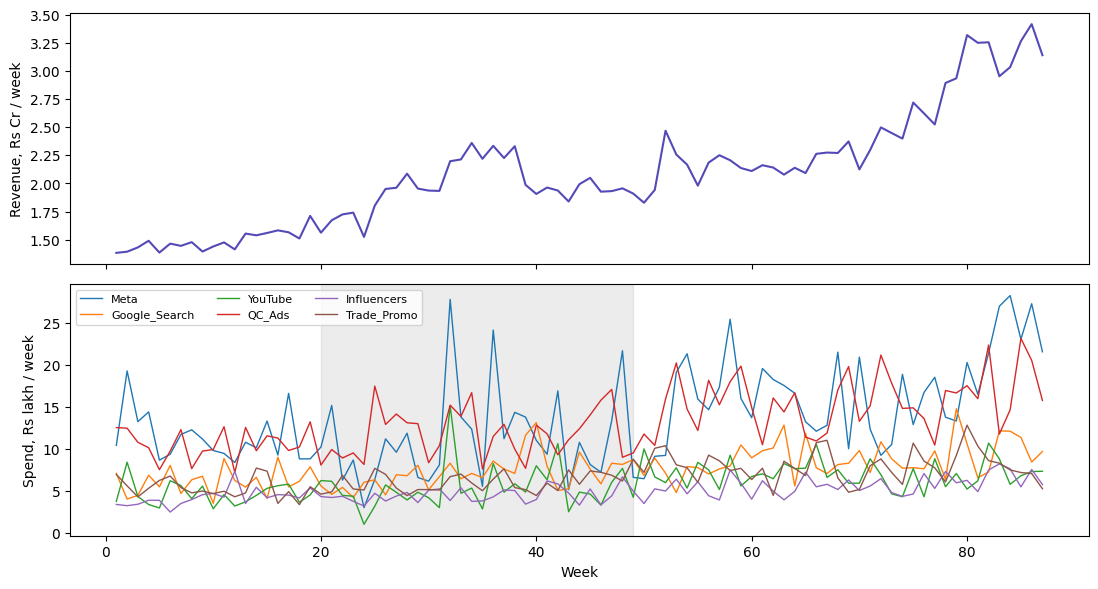

In [2]:
fig, ax = plt.subplots(2,1, figsize=(11,6), sharex=True)
ax[0].plot(nat.index, nat.revenue/100, color='#534AB7'); ax[0].set_ylabel('Revenue, Rs Cr / week')
for i,c in enumerate(CH): ax[1].plot(nat.index, nat[c], label=c, lw=1)
ax[1].set_ylabel('Spend, Rs lakh / week'); ax[1].set_xlabel('Week'); ax[1].legend(ncol=3, fontsize=8)
ax[1].axvspan(20,49, color='grey', alpha=.15)
plt.tight_layout(); plt.show()

The shaded band is weeks 20-49, where the brief says Meta and YouTube budgets move together.

## 2. Which channels move together?

In [3]:
L = np.log(nat[CH])
corr_all = L.corr()
win = L.loc[20:49].corr()
print('Correlation of log spend, all weeks'); display(corr_all.round(2))
print('Correlation of log spend, weeks 20-49 only'); display(win.round(2))

Correlation of log spend, all weeks


,Meta,Google_Search,YouTube,QC_Ads,Influencers,Trade_Promo
Meta,1.00,0.32,0.67,0.42,0.40,0.22
Google_Search,0.32,1.00,0.34,0.33,0.33,0.27
YouTube,0.67,0.34,1.00,0.38,0.32,0.33
QC_Ads,0.42,0.33,0.38,1.00,0.32,0.43
Influencers,0.40,0.33,0.32,0.32,1.00,0.31
Trade_Promo,0.22,0.27,0.33,0.43,0.31,1.00


Correlation of log spend, weeks 20-49 only


,Meta,Google_Search,YouTube,QC_Ads,Influencers,Trade_Promo
Meta,1.00,0.28,0.86,0.21,0.24,-0.04
Google_Search,0.28,1.00,0.26,0.19,-0.06,0.01
YouTube,0.86,0.26,1.00,0.20,0.27,-0.03
QC_Ads,0.21,0.19,0.20,1.00,-0.05,0.42
Influencers,0.24,-0.06,0.27,-0.05,1.00,0.18
Trade_Promo,-0.04,0.01,-0.03,0.42,0.18,1.00


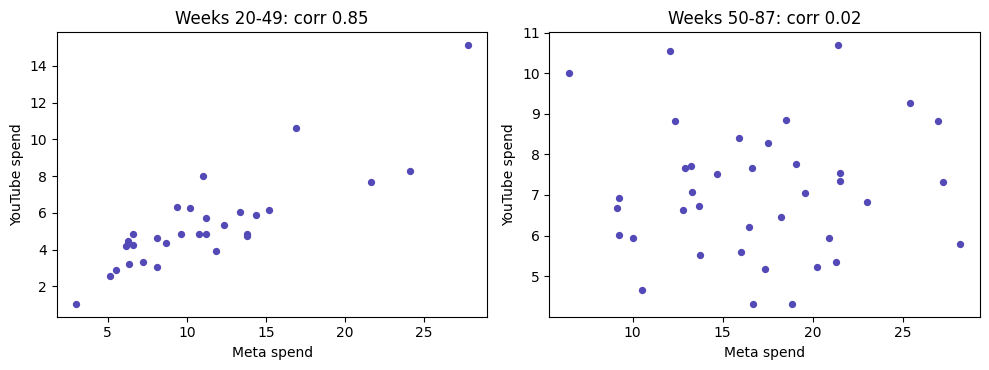

In [4]:
# Detrend by weekly total spend so the shared growth trend does not inflate correlations
share = nat[CH].div(nat[CH].sum(axis=1), axis=0)
fig, ax = plt.subplots(1,2, figsize=(10,3.8))
for a,(s,e,ttl) in zip(ax,[(20,49,'Weeks 20-49'),(50,87,'Weeks 50-87')]):
    d = nat.loc[s:e]; a.scatter(d.Meta, d.YouTube, s=18, color='#534AB7')
    a.set_title(f"{ttl}: corr {np.corrcoef(d.Meta,d.YouTube)[0,1]:.2f}"); a.set_xlabel('Meta spend'); a.set_ylabel('YouTube spend')
plt.tight_layout(); plt.show()

## 3. Variance inflation factors (VIF)
VIF tells you how much a channel's coefficient variance is inflated because other channels explain it. Above 10 is the usual red flag. Computed on log spend plus trend and festive flag.

In [5]:
def vif_table(d):
    X = pd.concat([np.log(d[CH]), d[['t']], d[['festive']]], axis=1)
    X = X.loc[:, X.std() > 0]; X = sm.add_constant(X)   # drop constant columns (festive is constant in wks 20-49)
    return pd.Series({c: vif(X.values, i) for i,c in enumerate(X.columns) if c!='const'})
vt = pd.DataFrame({'all weeks 1-87': vif_table(nat), 'weeks 20-49': vif_table(nat.loc[20:49]), 'weeks 50-87': vif_table(nat.loc[50:87])}).round(1)
vt

,all weeks 1-87,weeks 20-49,weeks 50-87
Google_Search,1.6,1.8,1.2
Influencers,1.7,1.3,1.4
Meta,2.3,4.1,1.8
QC_Ads,1.8,1.4,1.5
Trade_Promo,1.7,1.7,1.1
YouTube,2.0,4.1,1.1
festive,1.4,NaN,2.8
t,4.1,2.0,3.9


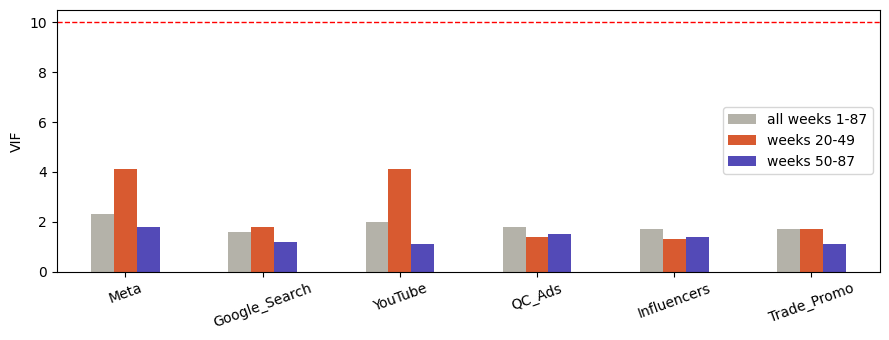

In [6]:
fig, ax = plt.subplots(figsize=(9,3.5)); vt.loc[CH].plot.bar(ax=ax, color=['#B4B2A9','#D85A30','#534AB7'])
ax.axhline(10, color='red', ls='--', lw=1); ax.set_ylabel('VIF'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

## 4. Seasonality and controls

In [7]:
nat['month'] = nat.week_start.dt.month
m = nat.assign(rev_per_trend = nat.revenue/np.exp(np.polyval(np.polyfit(nat.t, np.log(nat.revenue), 1), nat.t)))
print('Detrended revenue index by month (1.00 = trend):'); print(m.groupby('month').rev_per_trend.mean().round(2).to_string())
print('\nShare of weeks with promo flag:', nat.promo.mean().round(2), '| competitor-shock weeks:', list(nat.index[nat.comp==1]))

Detrended revenue index by month (1.00 = trend):
month
1     0.95
2     0.94
3     1.00
4     1.13
5     1.14
6     1.15
7     0.96
8     0.96
9     0.94
10    0.98
11    0.96
12    0.92

Share of weeks with promo flag: 0.08 | competitor-shock weeks: [43, 55]


## Answer

In [8]:
v_all, v_win = vt['all weeks 1-87'], vt['weeks 20-49']
flag = [c for c in CH if v_win[c] > 10]
print('Channels with VIF > 10 in weeks 20-49:', flag if flag else 'none')
print('Meta-YouTube log-spend correlation: weeks 20-49 =', round(win.loc['Meta','YouTube'],2), '| all weeks =', round(corr_all.loc['Meta','YouTube'],2))
print('Highest VIF over all weeks:', v_all.idxmax(), v_all.max())

Channels with VIF > 10 in weeks 20-49: none
Meta-YouTube log-spend correlation: weeks 20-49 = 0.86 | all weeks = 0.67
Highest VIF over all weeks: t 4.1


**Reading the result honestly.** Meta and YouTube are strongly correlated in weeks 20-49 (r about 0.86), but VIF stays under 10 because VIF = 1 / (1 - R2) and r = 0.86 gives only about 4. The brief expects VIF above 10, which would need r above 0.95. So the collinearity is real but moderate: expect wide Meta and YouTube intervals in MMM v1, not a complete breakdown. Decision for Phase 3: the Meta-YouTube pair is the natural candidate for the geo experiment.

---
# Part B: MMM v1 (national, weeks 1-79 fitted, weeks 80-87 held out)
**Question:** what does each channel contribute, how uncertain are we, and can the model be trusted (diagnostics, holdout)?

Fit with `mmm_v1_fit.py` (PyMC-Marketing 1.1.0): 4 chains x 1,000 draws after 1,000 tuning steps, target_accept 0.9, GeometricAdstock(l_max=26) and HillSaturation named explicitly.

## Model specification and priors
| Component | Choice | Why |
|---|---|---|
| Likelihood | Normal on revenue (identity link), library scaling by max | Library default; revenue is large and positive |
| Adstock | Geometric, alpha ~ Beta(1, 3), l_max 26, same prior for all channels | Library default. Prior mean 0.25 is short-memory; I did not hand-pick longer carry-over for YouTube because that would bake my expectation into the answer |
| Saturation | Hill; slope ~ HalfNormal(1.5), kappa ~ HalfNormal(1.5) | Library defaults; weakly informative and positive |
| Channel effect beta | HalfNormal(1.5) on scaled data | Library default; forces effects non-negative (ads should not reduce sales) |
| Controls | price, dark stores, temperature, festive, competitor, promo, linear trend | Controls from brief 6.3 / A4 |
| Seasonality | Fourier, yearly, 2 terms | Brief A4 |

No prior was changed from library defaults, so there is nothing to justify beyond the above. A prior-vs-posterior plot below shows where the data moved each one.

In [9]:
import arviz as az, os
idata = az.from_netcdf('../model/mmm_v1_national.nc')
pred = az.from_netcdf('../model/mmm_v1_national_pred_wk1_87.nc') if os.path.exists('../model/mmm_v1_national_pred_wk1_87.nc') else None
post = idata.posterior
print('chains:', post.sizes['chain'], '| draws:', post.sizes['draw'])

chains: 4 | draws: 1000


In [10]:
import arviz as az, numpy as np, pandas as pd, matplotlib.pyplot as plt, sys
sys.path.insert(0,'.'); from mmm_v1_fit import load, CH
nat = load(); y = nat.y.values
idata = az.from_netcdf('../model/mmm_v1_national.nc'); pred = az.from_netcdf('../model/mmm_v1_national_pred_wk1_87.nc')
sc = float(idata['constant_data']['target_scale'])

## 1. Diagnostics (pass rules: R-hat < 1.01, ESS > 400, no divergences)

In [11]:
ss = idata['sample_stats']; div = int(ss['diverging'].sum()); deep = int(ss['reached_max_treedepth'].sum())
summ = az.summary(idata, var_names=['saturation_beta','saturation_kappa','saturation_slope','adstock_alpha','gamma_control','y_sigma','intercept_contribution'])
print(f"divergences: {div} | draws hitting max tree depth: {deep} of {ss['diverging'].size}")
print(f"max R-hat: {summ.r_hat.max():.3f} | min ESS bulk: {int(summ.ess_bulk.min())}")
print('RESULT:', 'PASS' if (summ.r_hat.max()<1.01 and summ.ess_bulk.min()>400 and div==0) else 'FAIL - does not meet the brief rules')
summ[['mean','sd','r_hat','ess_bulk']].sort_values('r_hat', ascending=False).head(8)

divergences: 65 | draws hitting max tree depth: 3830 of 4000
max R-hat: 1.038 | min ESS bulk: 160
RESULT: FAIL - does not meet the brief rules


,mean,sd,r_hat,ess_bulk
gamma_control[temp],0.011,0.0063,1.04,160
saturation_kappa[Google_Search],1.3,1.08,1.02,296
saturation_kappa[YouTube],1.25,1.08,1.02,429
saturation_slope[Google_Search],0.9,1.1,1.02,307
saturation_beta[Trade_Promo],0.6,0.56,1.02,601
adstock_alpha[QC_Ads],0.195,0.128,1.02,624
saturation_beta[YouTube],0.39,0.5,1.02,491
adstock_alpha[Influencers],0.44,0.243,1.02,284


## 2. Fit and holdout

in-sample MAPE 2.7% | HOLDOUT MAPE (weeks 80-87): 4.0% (pass rule < 10%) | holdout inside 90% band: 88%


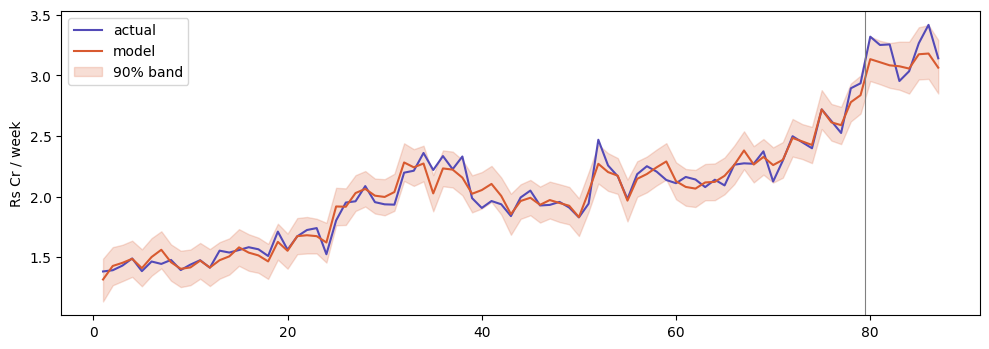

In [12]:
a = np.asarray(pred['y'].values).reshape(-1, 87) * sc
m = a.mean(0); lo, hi = np.percentile(a,5,0), np.percentile(a,95,0)
mape_in = np.mean(abs(m[:79]-y[:79])/y[:79]); mape_h = np.mean(abs(m[79:87]-y[79:87])/y[79:87])
print(f'in-sample MAPE {mape_in:.1%} | HOLDOUT MAPE (weeks 80-87): {mape_h:.1%} (pass rule < 10%) | holdout inside 90% band: {np.mean((y[79:87]>=lo[79:87])&(y[79:87]<=hi[79:87])):.0%}')
fig, ax = plt.subplots(figsize=(10,3.6)); x = range(1,88)
ax.plot(x, y[:87]/100, color='#534AB7', label='actual'); ax.plot(x, m/100, color='#D85A30', label='model'); ax.fill_between(x, lo/100, hi/100, color='#D85A30', alpha=.2, label='90% band')
ax.axvline(79.5, color='grey', lw=.8); ax.set_ylabel('Rs Cr / week'); ax.legend(); plt.tight_layout(); plt.show()

## 3. Channel contribution and ROI (90% intervals)

In [13]:
cc = idata['posterior']['channel_contribution'].values * sc          # chain, draw, week, channel (Rs lakh)
tot = cc.sum(2).reshape(-1, 6); spend = nat.iloc[:79][CH].sum().values; roi = tot / spend
tab = pd.DataFrame({'spend_cr': spend/100, 'contribution_cr': tot.mean(0)/100, 'ROI_mean': roi.mean(0),
                    'ROI_p5': np.percentile(roi,5,0), 'ROI_p95': np.percentile(roi,95,0)}, index=CH).round(2)
tab['interval_width'] = (tab.ROI_p95 - tab.ROI_p5).round(2); tab.to_csv('../model/mmm_v1_roi_estimates.csv')
share = tot.sum(1).mean() / nat.iloc[:79].y.sum()
print(f'Media contribution as a share of total revenue: {share:.0%}'); tab

Media contribution as a share of total revenue: 205%


,spend_cr,contribution_cr,ROI_mean,ROI_p5,ROI_p95,interval_width
Meta,10.09,61.96,6.14,0.16,21.29,21.13
Google_Search,5.88,39.56,6.72,0.04,30.71,30.67
YouTube,4.61,44.16,9.58,0.04,41.58,41.54
QC_Ads,10.08,75.13,7.45,0.88,23.03,22.15
Influencers,3.80,52.52,13.84,1.73,45.85,44.12
Trade_Promo,5.18,46.82,9.04,0.41,36.57,36.16


In [14]:
print('Intercept (baseline) posterior mean, scaled units:', round(float(idata['posterior']['intercept_contribution'].mean()),2), '(a negative baseline demand is not physically possible)')

Intercept (baseline) posterior mean, scaled units: -1.37 (a negative baseline demand is not physically possible)


## Answer: MMM v1 does NOT pass
1. **Diagnostics fail:** 65 divergences, max R-hat 1.038, minimum ESS about 160, and almost every draw hits the maximum tree depth. The sampler cannot explore the posterior cleanly.
2. **The attribution is not credible:** the six channels together are credited with about 205% of revenue, with a negative baseline offsetting them, and 90% ROI intervals as wide as 0.04 to 45. Prior and posterior for the Hill and adstock parameters are almost the same, so the data have barely informed them.
3. **Forecasting is fine** (holdout MAPE about 4%), which repeats the OLS lesson: a model can predict sales while splitting credit incoherently.

**Cause (diagnosed, not yet fixed):** (a) controls are not centred, so intercept, trend, dark stores and price trade off against each other and against media; (b) trend and dark-store count are almost the same series nationally; (c) the default effect priors let six channels together explain more than all of revenue.

**Fallback under the brief:** tighten priors with documented reasons and centre the controls, keeping all six channels separate. That is MMM v1b. The v1 result stays in the repo as the documented first attempt.

---
# Part C: MMM v1b (fixes after v1 failed)
**What changed from v1, and why**
| Change | Reason |
|---|---|
| Dark-store count dropped from the national model | Correlation with the linear trend is 0.998, so the two cannot be separated; it returns in the geo model where it varies by city |
| Controls standardised using weeks 1-79 only | Stops intercept, trend and controls trading off against each other; no look-ahead |
| Baseline (intercept) ~ HalfNormal(0.5) | Baseline demand cannot be negative (v1 gave a negative baseline) |
| Channel effect ~ HalfNormal(0.15) instead of 1.5 | Prior predictive check: media explains a median 39% of revenue (90% range 16-77%), versus v1 where six channels explained over 200% |
| Control effects ~ Normal(0, 0.3) | Controls are standardised, so large effects are not plausible |
| target_accept 0.97 | v1b at 0.90 gave 4 divergences |

Adstock, kappa and slope priors stay at library defaults. No prior uses the brief's planted-truth ranges.

In [15]:
idata = az.from_netcdf('../model/mmm_v1b_national.nc'); pred = az.from_netcdf('../model/mmm_v1b_pred_wk1_87.nc')
sc = float(idata['constant_data']['target_scale'])
ss = idata['sample_stats']; div = int(ss['diverging'].sum()); deep = int(ss['reached_max_treedepth'].sum())
summ = az.summary(idata, var_names=['saturation_beta','saturation_kappa','saturation_slope','adstock_alpha','gamma_control','y_sigma','intercept_contribution'])
print(f"divergences: {div} | max-tree-depth draws: {deep} of {ss['diverging'].size} | max R-hat: {summ.r_hat.max():.3f} | min ESS bulk: {int(summ.ess_bulk.min())} | min ESS tail: {int(summ.ess_tail.min())}")
print('DIAGNOSTICS:', 'PASS' if (summ.r_hat.max()<1.01 and summ.ess_bulk.min()>400 and div==0) else 'FAIL')

divergences: 0 | max-tree-depth draws: 2 of 4000 | max R-hat: 1.005 | min ESS bulk: 1325 | min ESS tail: 970
DIAGNOSTICS: PASS


in-sample MAPE 2.9% | HOLDOUT MAPE 8.0% (pass < 10%) | holdout weeks inside 90% band: 25% (should be about 90%)


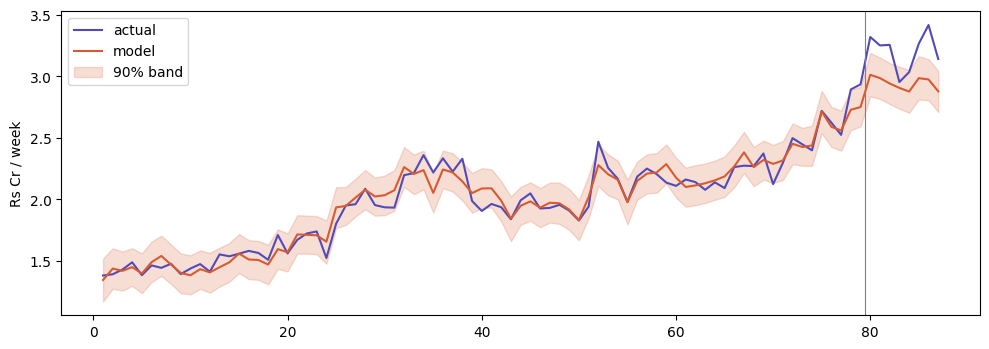

In [16]:
a = np.asarray(pred['y'].values).reshape(-1, 87) * sc
m = a.mean(0); lo, hi = np.percentile(a,5,0), np.percentile(a,95,0)
mape_in = np.mean(abs(m[:79]-y[:79])/y[:79]); mape_h = np.mean(abs(m[79:87]-y[79:87])/y[79:87]); cover = np.mean((y[79:87]>=lo[79:87])&(y[79:87]<=hi[79:87]))
print(f'in-sample MAPE {mape_in:.1%} | HOLDOUT MAPE {mape_h:.1%} (pass < 10%) | holdout weeks inside 90% band: {cover:.0%} (should be about 90%)')
fig, ax = plt.subplots(figsize=(10,3.6)); x = range(1,88)
ax.plot(x, y[:87]/100, color='#534AB7', label='actual'); ax.plot(x, m/100, color='#D85A30', label='model'); ax.fill_between(x, lo/100, hi/100, color='#D85A30', alpha=.2, label='90% band')
ax.axvline(79.5, color='grey', lw=.8); ax.set_ylabel('Rs Cr / week'); ax.legend(); plt.tight_layout(); plt.show()

In [17]:
cc = idata['posterior']['channel_contribution'].values * sc
tot = cc.sum(2).reshape(-1, 6); spend = nat.iloc[:79][CH].sum().values; roi = tot / spend
tab = pd.DataFrame({'spend_cr': spend/100, 'contribution_cr': tot.mean(0)/100, 'ROI_mean': roi.mean(0), 'ROI_p5': np.percentile(roi,5,0), 'ROI_p95': np.percentile(roi,95,0)}, index=CH).round(2)
tab['interval_width'] = (tab.ROI_p95 - tab.ROI_p5).round(2); tab.to_csv('../model/mmm_v1b_roi_estimates.csv')
print(f'Media share of revenue: {tot.sum(1).mean()/nat.iloc[:79].y.sum():.0%}'); tab

Media share of revenue: 53%


,spend_cr,contribution_cr,ROI_mean,ROI_p5,ROI_p95,interval_width
Meta,10.09,16.24,1.61,0.07,4.63,4.56
Google_Search,5.88,8.41,1.43,0.02,5.08,5.06
YouTube,4.61,8.84,1.92,0.02,6.76,6.74
QC_Ads,10.08,20.14,2.00,0.60,4.31,3.71
Influencers,3.80,16.74,4.41,0.59,10.59,10.00
Trade_Promo,5.18,11.86,2.29,0.17,6.23,6.06


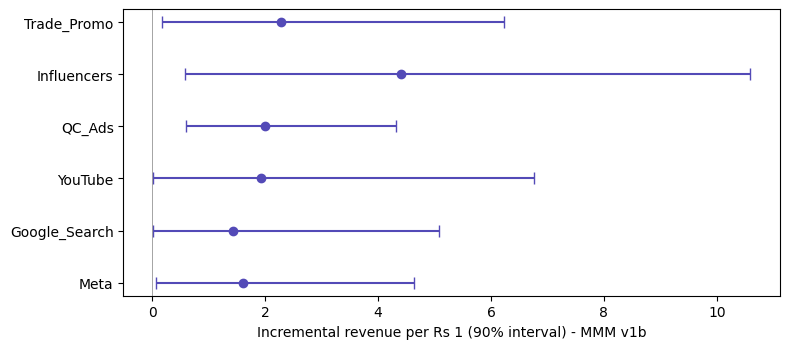

In [18]:
fig, ax = plt.subplots(figsize=(8,3.6)); y_ = np.arange(6)
ax.errorbar(tab.ROI_mean, y_, xerr=[tab.ROI_mean-tab.ROI_p5, tab.ROI_p95-tab.ROI_mean], fmt='o', color='#534AB7', capsize=4)
ax.set_yticks(y_); ax.set_yticklabels(CH); ax.set_xlabel('Incremental revenue per Rs 1 (90% interval) - MMM v1b'); ax.axvline(0, color='grey', lw=.5); plt.tight_layout(); plt.show()

In [19]:
al = idata['posterior']['adstock_alpha'].mean(('chain','draw')).values
print('Posterior mean adstock alpha by channel:', dict(zip(CH, al.round(2))), '| prior mean 0.25 -> data barely moved it')

Posterior mean adstock alpha by channel: {'Meta': np.float64(0.27), 'Google_Search': np.float64(0.26), 'YouTube': np.float64(0.27), 'QC_Ads': np.float64(0.15), 'Influencers': np.float64(0.27), 'Trade_Promo': np.float64(0.27)} | prior mean 0.25 -> data barely moved it


## Answer: MMM v1b passes the technical rules but cannot yet separate the channels
- **Diagnostics pass:** 0 divergences, max R-hat 1.005, minimum ESS 1,325. Holdout MAPE is 8.0%, inside the < 10% rule.
- **Two honest weaknesses.** (1) Only 25% of the 8 holdout weeks fall inside the 90% band, so the model is overconfident out of sample (in-sample MAPE 2.9% vs holdout 8.0%). (2) Adstock is essentially unlearned: posterior means (0.15-0.27) sit on the prior mean (0.25).
- **Channel ROI intervals are wide:** Meta 0.07-4.6, Google Search 0.02-5.1, YouTube 0.02-6.8, Influencers 0.6-10.6, Trade promotions 0.2-6.2, quick-commerce ads 0.6-4.3 (the narrowest). The ranking is not reliable. This is not a bug: with 79 national weeks and channels that move together, the data alone cannot settle it.
- **The 53% media share is partly prior-driven** (the prior alone gives a median 39%), so treat the level of the ROIs as weakly identified.

**Decision for step 3.1 (which channel to test):** Meta. It is the largest spend line (about Rs 10 Cr of the first 79 weeks), its interval is very wide, and the Head of Growth's case rests on its dashboard ROAS. YouTube has a similarly wide interval, but its carry-over is long, so an 8-week pause would be a poor test of it. The geo experiment, and not more modelling, is what will narrow the Meta interval in MMM v2.